# 三策略对比：现状2020(基准) vs 扩容 vs 定容

对每个未来气候情景画一张图，每个城市三根柱子：

- **Baseline (2020)**：现状空调 + 2020 气候，作为参照基线
- **Capacity Expansion**：扩容空调 + 该未来气候情景
- **Fixed Capacity**：定容空调 + 该未来气候情景

可以看出"如果未来气候变成 2040 RCP 4.5，扩容/定容能比现状好多少"。

In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
from config.paths import PER_CAPITA_OUTPUT_DIR, FIGURES_DIR
from src.plotting.grouped_bar import plot_strategy_grouped

SCENARIO_FILTER = '2020 Baseline'  # 可改成 '2040 RCP 4.5' 等

In [2]:
df = pd.read_csv(os.path.join(PER_CAPITA_OUTPUT_DIR, 'per_capita_hours_summary.csv'))

# 现状2020作为基准线（所有未来情景都会跟它对比）
baseline_2020 = df[(df['策略'] == '现状') & (df['情景'] == '2020 Baseline')].copy()

# 未来情景的扩容和定容数据
future_scenarios = df[df['情景'] != '2020 Baseline'].copy()

df.head()

,策略,城市,城市拼音,情景,Total_Person_Hours,Total_Population,Hours_Per_Resident,城市标签
0,现状,北京市,bei3jing1shi4,2020 Baseline,6.084353e+06,5.900282e+06,1.031197,Bei3jing1s
1,扩容,北京市,bei3jing1shi4,2040 RCP 2.6,1.150382e+07,5.900282e+06,1.949708,Bei3jing1s
2,扩容,北京市,bei3jing1shi4,2040 RCP 4.5,1.608852e+07,5.900282e+06,2.726738,Bei3jing1s
3,扩容,北京市,bei3jing1shi4,2040 RCP 8.5,2.601935e+07,5.900282e+06,4.409849,Bei3jing1s
4,扩容,北京市,bei3jing1shi4,2060 RCP 2.6,3.629018e+07,5.900282e+06,6.150585,Bei3jing1s


✅ 图已保存: e:\cc data\thermal_comfort_analysis\results\figures\three_strategies_2040_RCP_4.5.png


,城市,策略,情景,Hours_Per_Resident
9,上海市,定容,2040 RCP 4.5,26.757920
8,上海市,扩容,2040 RCP 4.5,25.465646
1,上海市,现状,2040 RCP 4.5,9.703264
7,北京市,定容,2040 RCP 4.5,3.608752
6,北京市,扩容,2040 RCP 4.5,2.726738
0,北京市,现状,2040 RCP 4.5,1.031197
17,厦门市,定容,2040 RCP 4.5,42.475974
16,厦门市,扩容,2040 RCP 4.5,40.799608
5,厦门市,现状,2040 RCP 4.5,16.480724
11,广州市,定容,2040 RCP 4.5,39.768445


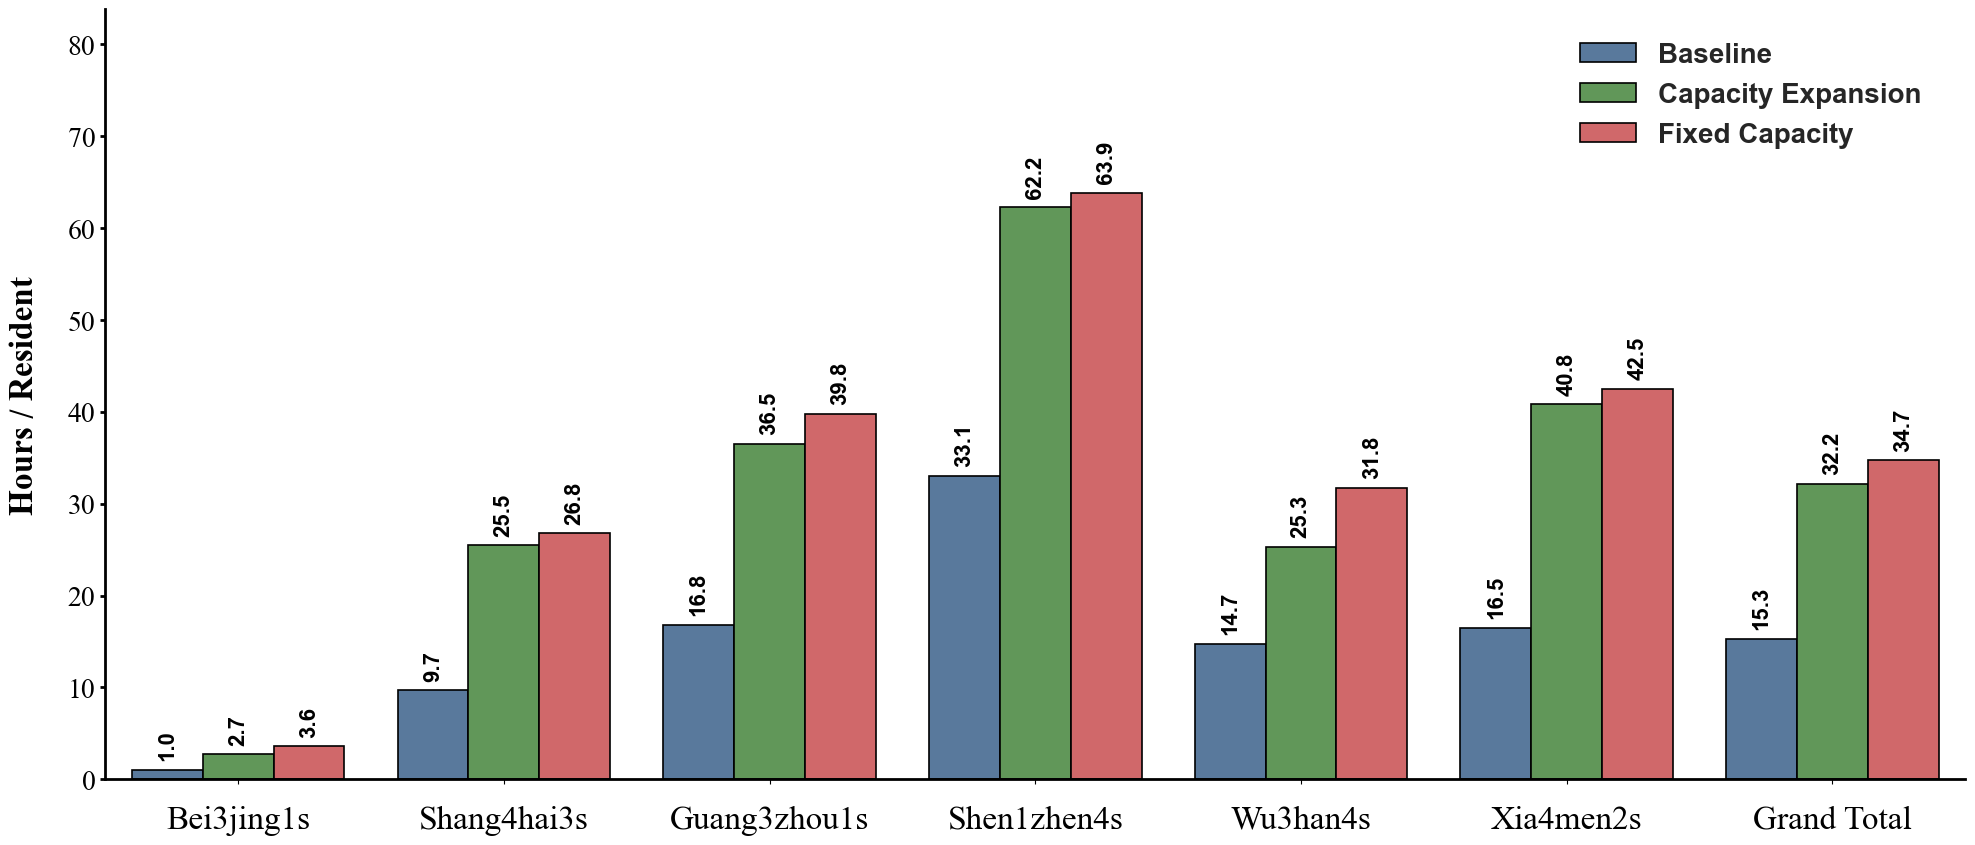

In [3]:
# 示例：画一个情景的三策略对比（2040 RCP 4.5）
SCENARIO_FILTER = '2040 RCP 4.5'

# 组合数据：现状2020 + 该情景的扩容/定容
baseline_copy = baseline_2020.copy()
baseline_copy['情景'] = SCENARIO_FILTER  # 改成当前情景名，方便对比
df_scenario = future_scenarios[future_scenarios['情景'] == SCENARIO_FILTER].copy()
df_plot = pd.concat([baseline_copy, df_scenario], ignore_index=True)

safe_label = SCENARIO_FILTER.replace(' ', '_')
save_path = os.path.join(FIGURES_DIR, f'three_strategies_{safe_label}.png')
fig, ax = plot_strategy_grouped(df_plot, save_path=save_path)
df_plot[['城市', '策略', '情景', 'Hours_Per_Resident']].sort_values(['城市', '策略'])

## 多情景对比（可选）

下面的 cell 会循环画出所有情景的三策略对比图。

✅ 图已保存: e:\cc data\thermal_comfort_analysis\results\figures\three_strategies_2040_RCP_2.6.png
✅ 2040 RCP 2.6
✅ 图已保存: e:\cc data\thermal_comfort_analysis\results\figures\three_strategies_2040_RCP_4.5.png
✅ 2040 RCP 4.5
✅ 图已保存: e:\cc data\thermal_comfort_analysis\results\figures\three_strategies_2040_RCP_8.5.png
✅ 2040 RCP 8.5
✅ 图已保存: e:\cc data\thermal_comfort_analysis\results\figures\three_strategies_2060_RCP_2.6.png
✅ 2060 RCP 2.6
✅ 图已保存: e:\cc data\thermal_comfort_analysis\results\figures\three_strategies_2060_RCP_4.5.png
✅ 2060 RCP 4.5
✅ 图已保存: e:\cc data\thermal_comfort_analysis\results\figures\three_strategies_2060_RCP_8.5.png
✅ 2060 RCP 8.5


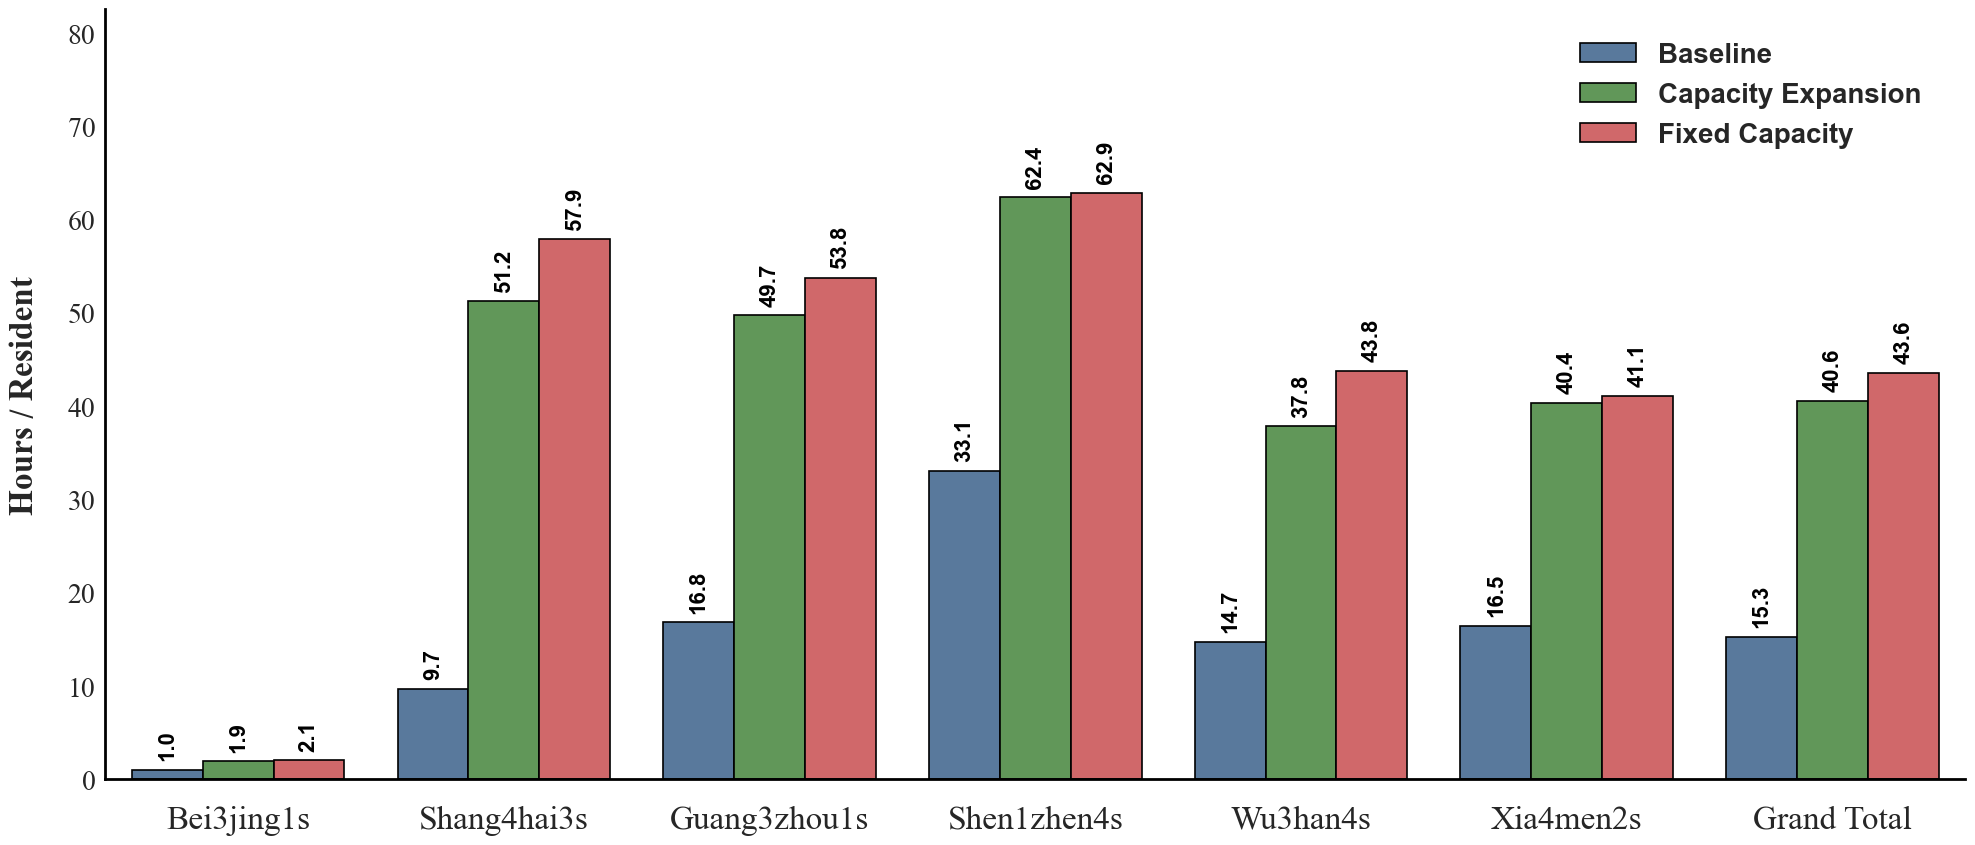

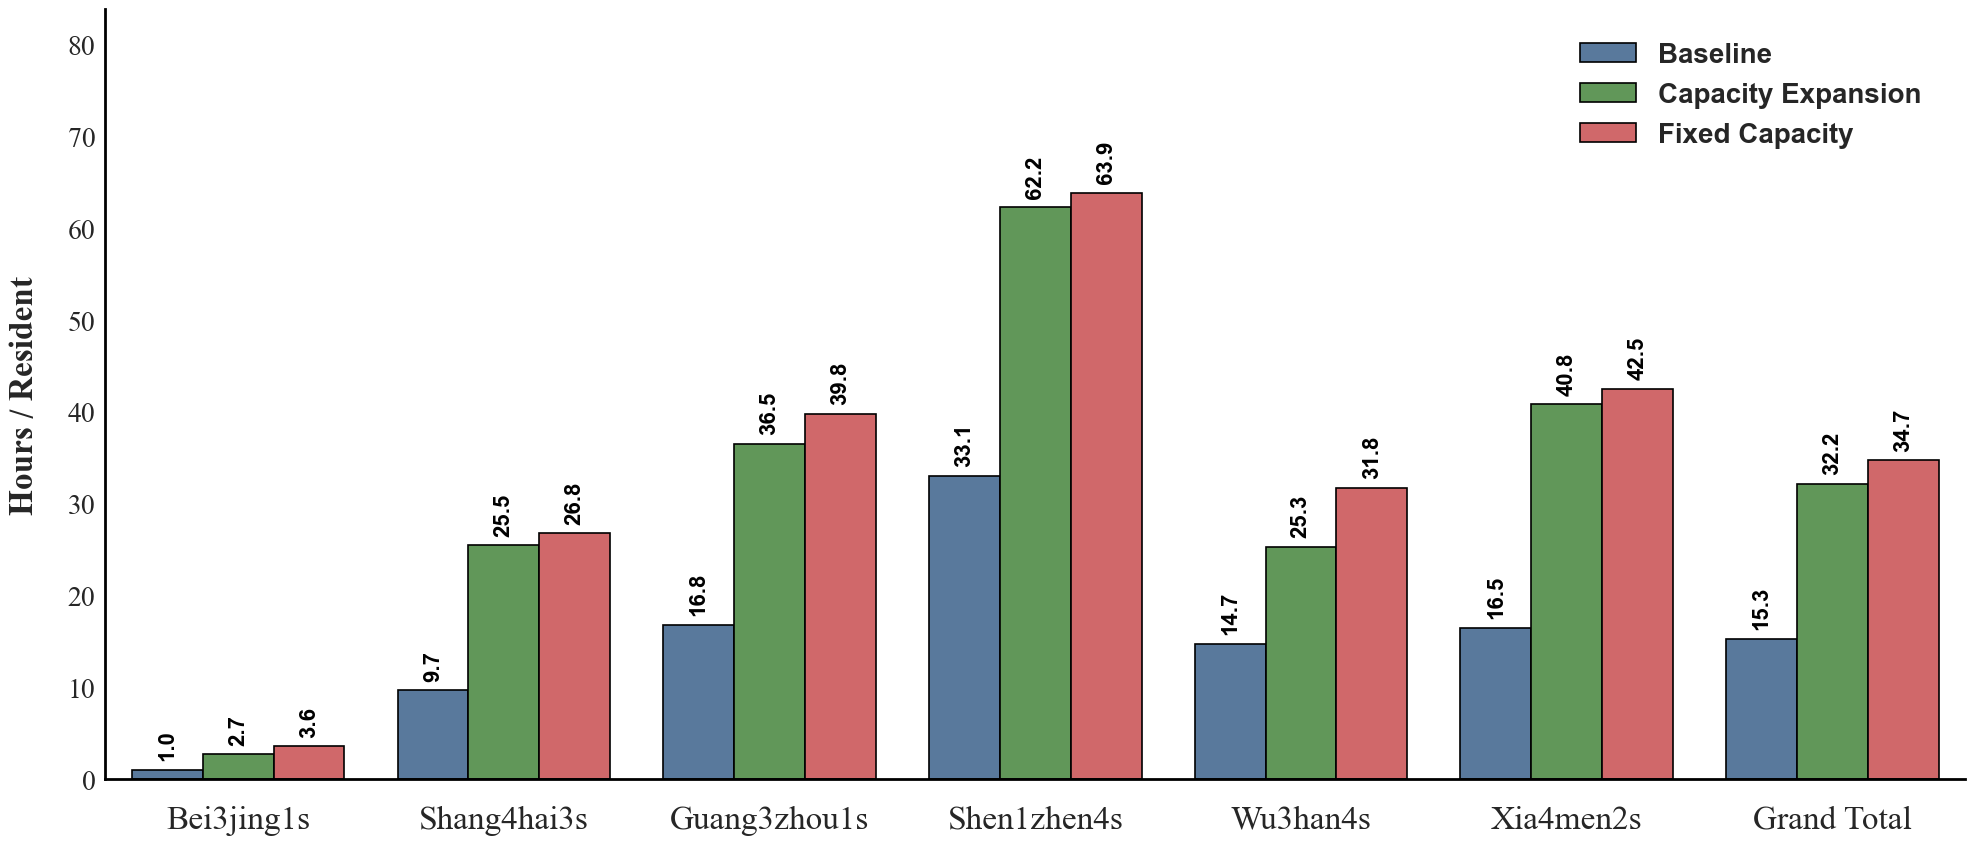

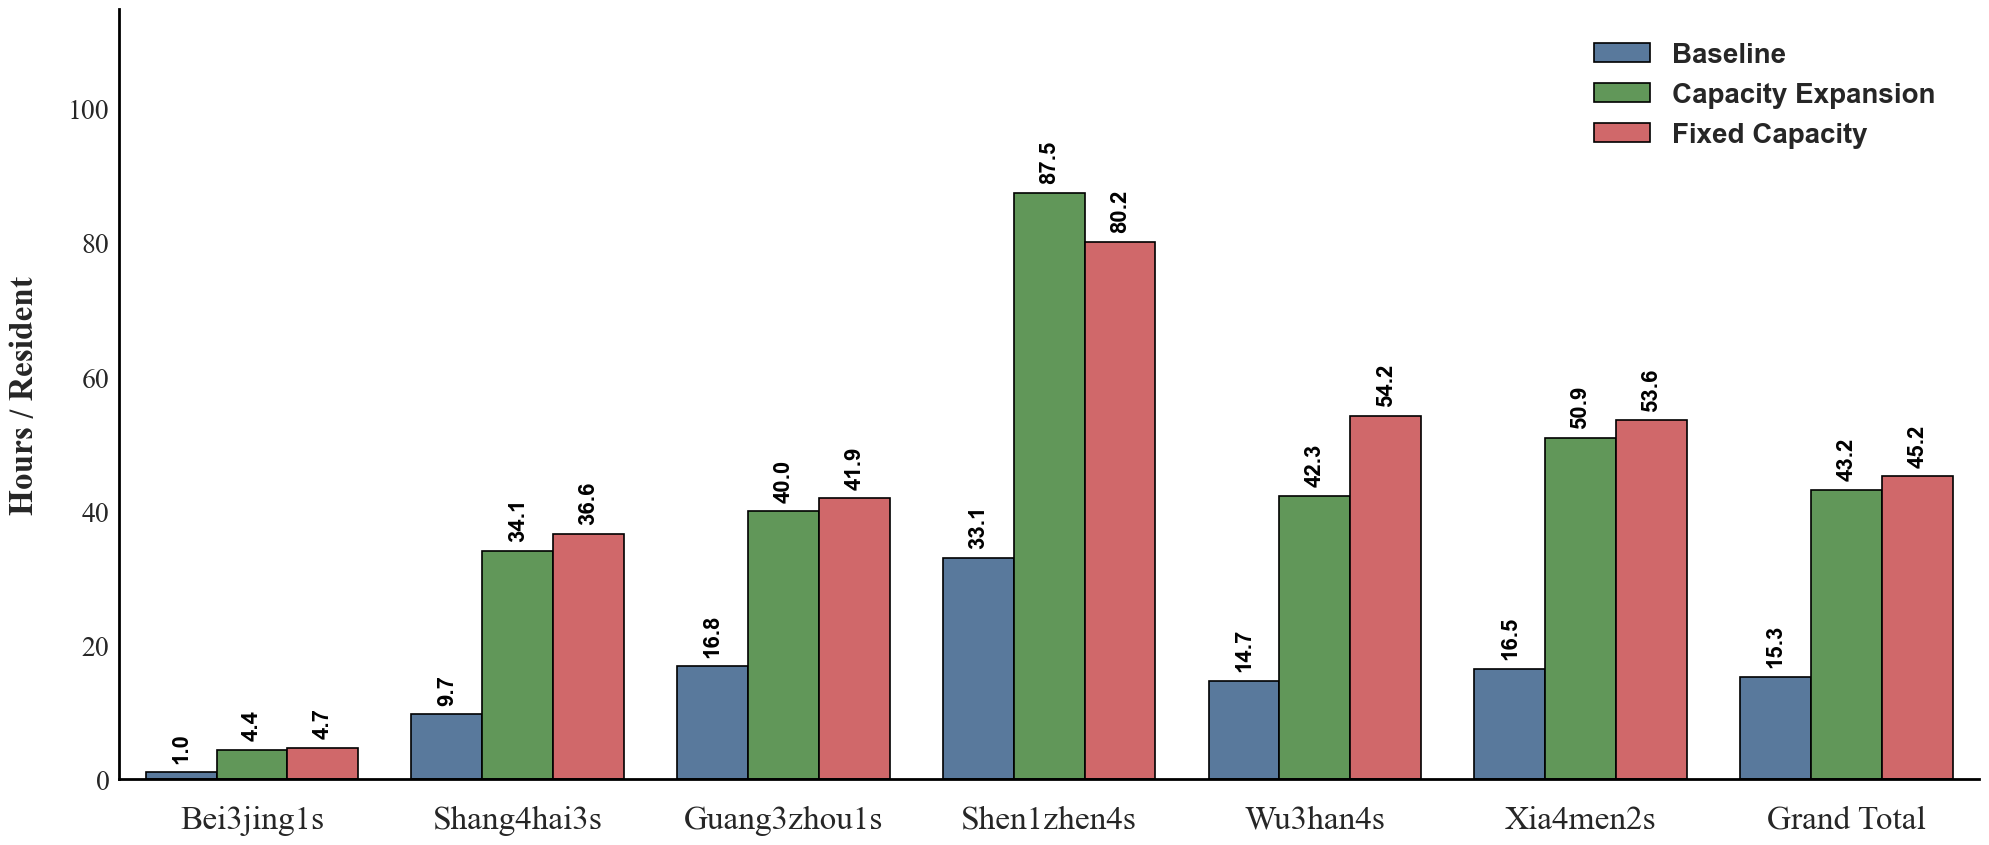

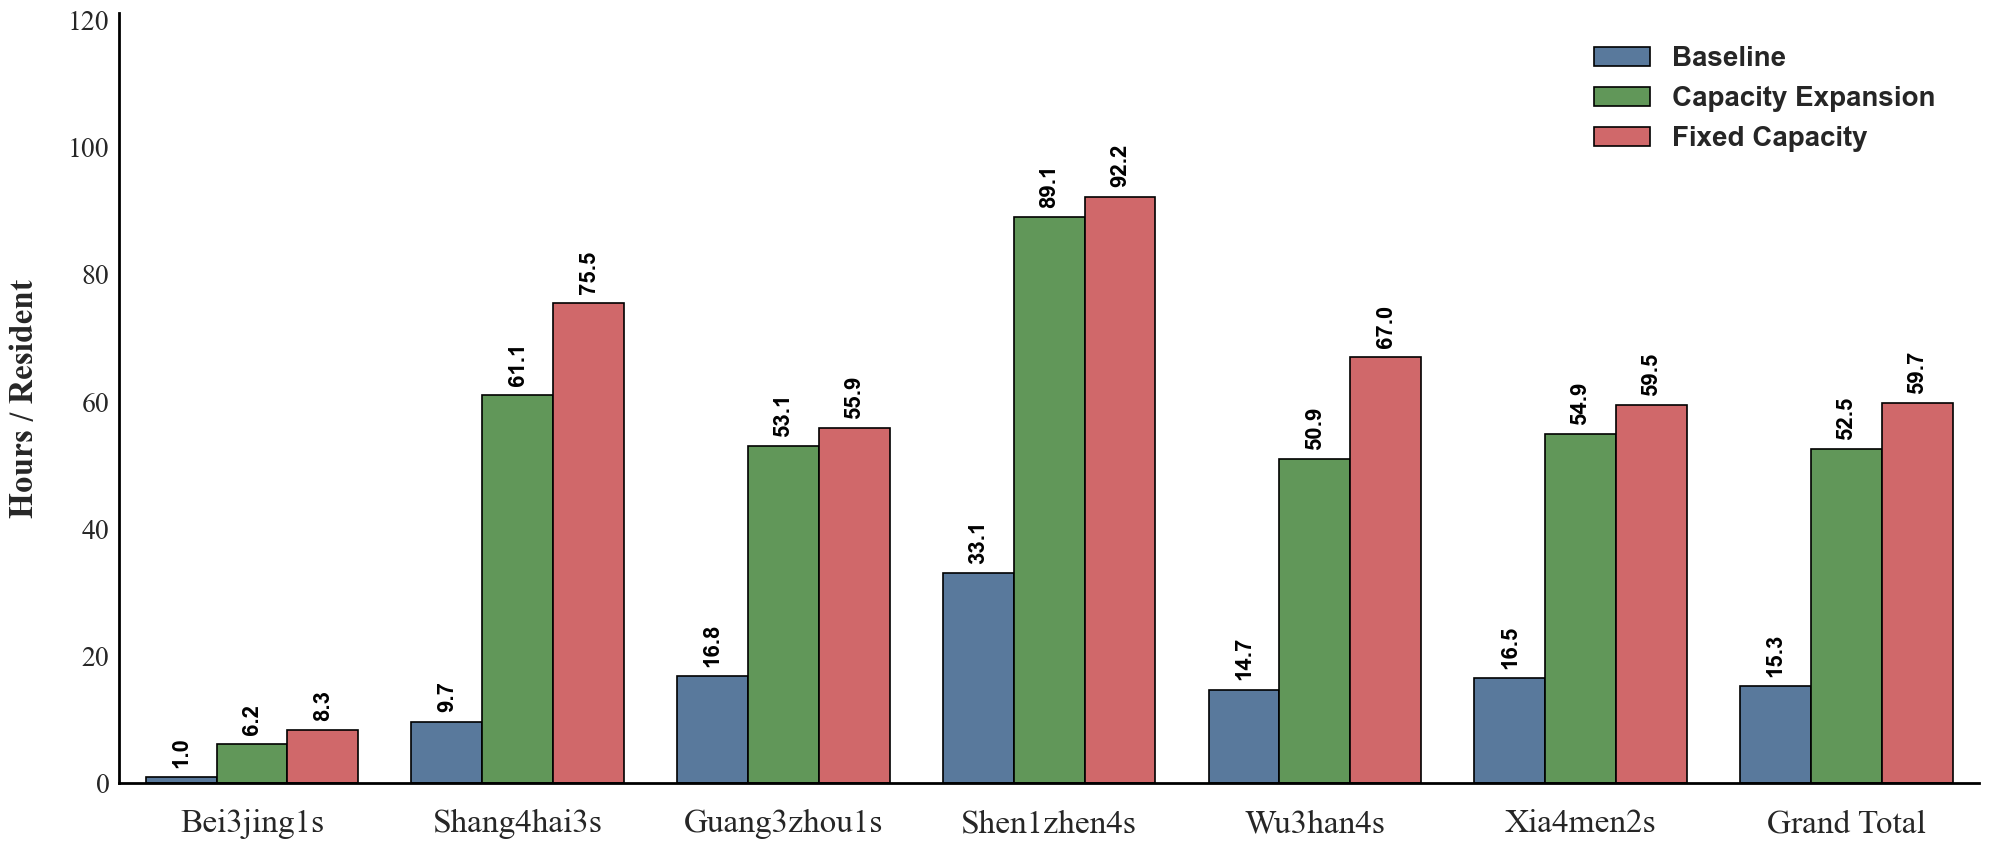

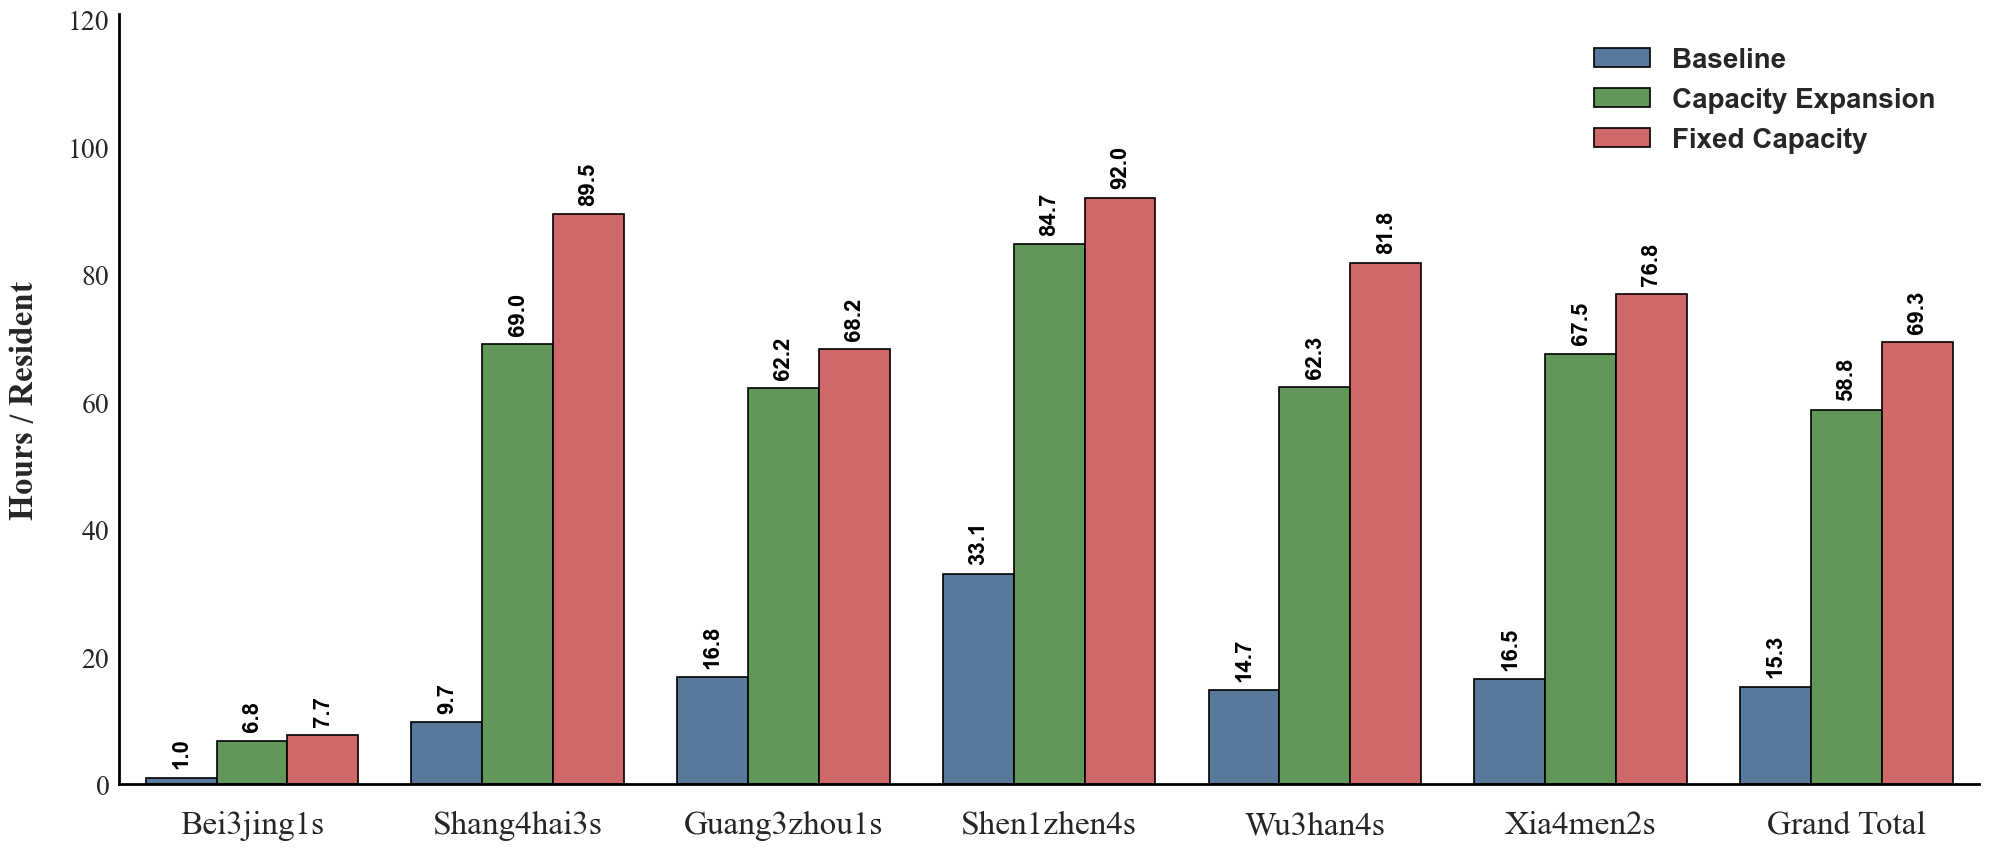

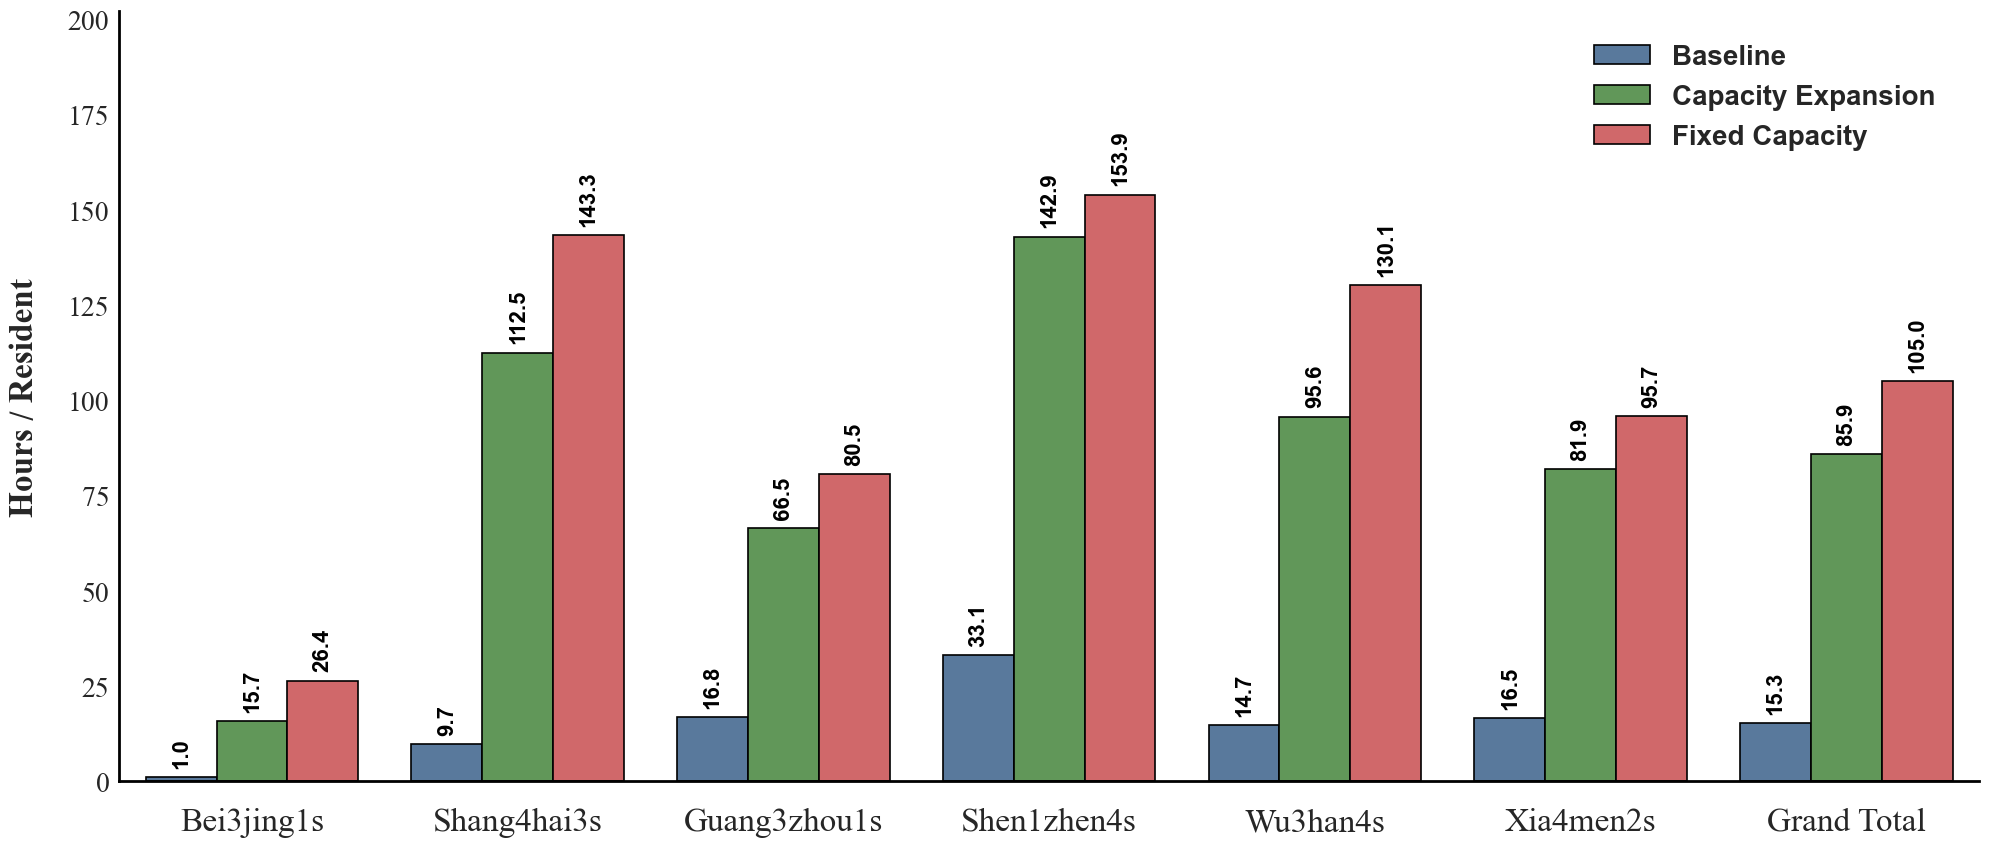

In [4]:
from config.parameters import SCENARIO_ORDER

# 循环画出所有未来情景的三策略对比图
for scen in SCENARIO_ORDER:
    if scen == '2020 Baseline':
        continue  # 跳过基准年
    
    df_scen = future_scenarios[future_scenarios['情景'] == scen].copy()
    if df_scen.empty:
        continue
    
    # 把现状2020作为基准线加进来
    baseline_copy = baseline_2020.copy()
    baseline_copy['情景'] = scen
    df_p = pd.concat([baseline_copy, df_scen], ignore_index=True)
    
    safe = scen.replace(' ', '_')
    sp = os.path.join(FIGURES_DIR, f'three_strategies_{safe}.png')
    plot_strategy_grouped(df_p, save_path=sp)
    print(f'✅ {scen}')